In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/72_unsharp_clahe_augmented_6.png
/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/49_unsharp_clahe_augmented_1.png
/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/57_unsharp_clahe_augmented_1.png
/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/97_unsharp_clahe_augmented_3.png
/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/60_unsharp_clahe_augmented_4.png
/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/100_unsharp_clahe_augmented_3.png
/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/healthy_guava/26_unsharp_clahe_augmented_1.png
/kaggle/input/datasets/habibsalehinshamu

In [3]:
# Install timm — provides pretrained DeiT and many other vision models
!pip install timm -q

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Torchvision
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder

# timm — where the pretrained DeiT model comes from
import timm

# Scikit-learn — for evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

# PIL — for single image loading in the inference cell
from PIL import Image

print("All imports successful.")
print(f"PyTorch  : {torch.__version__}")
print(f"timm     : {timm.__version__}")

All imports successful.
PyTorch  : 2.9.0+cu126
timm     : 1.0.24


In [4]:
def set_seed(seed=42):
    """Fix random seeds across Python, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Prefer GPU; fall back to CPU if no GPU is found
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla P100-PCIE-16GB


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CHANGE THESE PATHS to match your Kaggle dataset name.
# In the Kaggle notebook sidebar click "Data" → hover over your dataset →
# copy the path shown, then paste the folder name below.
# ─────────────────────────────────────────────────────────────────────────────
TRAIN_DIR = "/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/train"   # <-- change 'guava-dataset'
VAL_DIR   = "/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val"   # <-- same slug here
TEST_DIR  = "/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/test"    # <-- and here

IMG_SIZE   = 224    # DeiT expects 224 x 224
BATCH_SIZE = 32     # 32 fits comfortably on a P100

# ImageNet statistics — mandatory because DeiT was pretrained with them
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Training transforms (with augmentation) ───────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),            # resize slightly larger first
    transforms.RandomCrop(IMG_SIZE),          # random crop to 224
    transforms.RandomHorizontalFlip(),        # random left-right flip
    transforms.ColorJitter(                   # mild colour variation
        brightness=0.2, contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)           # ImageNet normalisation
])

# ── Validation / test transforms (no augmentation) ────────────────────────────
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # direct resize to 224
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

print("Transforms ready.")
print(f"  Train dir : {TRAIN_DIR}")
print(f"  Val dir   : {VAL_DIR}")
print(f"  Test dir  : {TEST_DIR}")

Transforms ready.
  Train dir : /kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/train
  Val dir   : /kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val
  Test dir  : /kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/test


In [6]:
# ImageFolder maps each subfolder to a class label automatically.
# Expected layout inside each split:
#   train/Anthracnose/
#   train/Fruit Flies/
#   train/Healthy fruits/
train_dataset = ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset   = ImageFolder(root=VAL_DIR,   transform=val_test_transforms)
test_dataset  = ImageFolder(root=TEST_DIR,  transform=val_test_transforms)

# DataLoaders handle batching, shuffling, and parallel data loading
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

# Class metadata
NUM_CLASSES  = len(train_dataset.classes)
CLASS_NAMES  = train_dataset.classes
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

print(f"Number of classes : {NUM_CLASSES}")
print(f"Class names       : {CLASS_NAMES}")
print(f"Class → index map : {train_dataset.class_to_idx}")
print()
print(f"Train   : {len(train_dataset):,} images  |  {len(train_loader)} batches")
print(f"Valid   : {len(val_dataset):,} images  |  {len(val_loader)} batches")
print(f"Test    : {len(test_dataset):,} images  |  {len(test_loader)} batches")

Number of classes : 3
Class names       : ['Anthracnose', 'fruit_fly', 'healthy_guava']
Class → index map : {'Anthracnose': 0, 'fruit_fly': 1, 'healthy_guava': 2}

Train   : 2,647 images  |  83 batches
Valid   : 755 images  |  24 batches
Test    : 382 images  |  12 batches


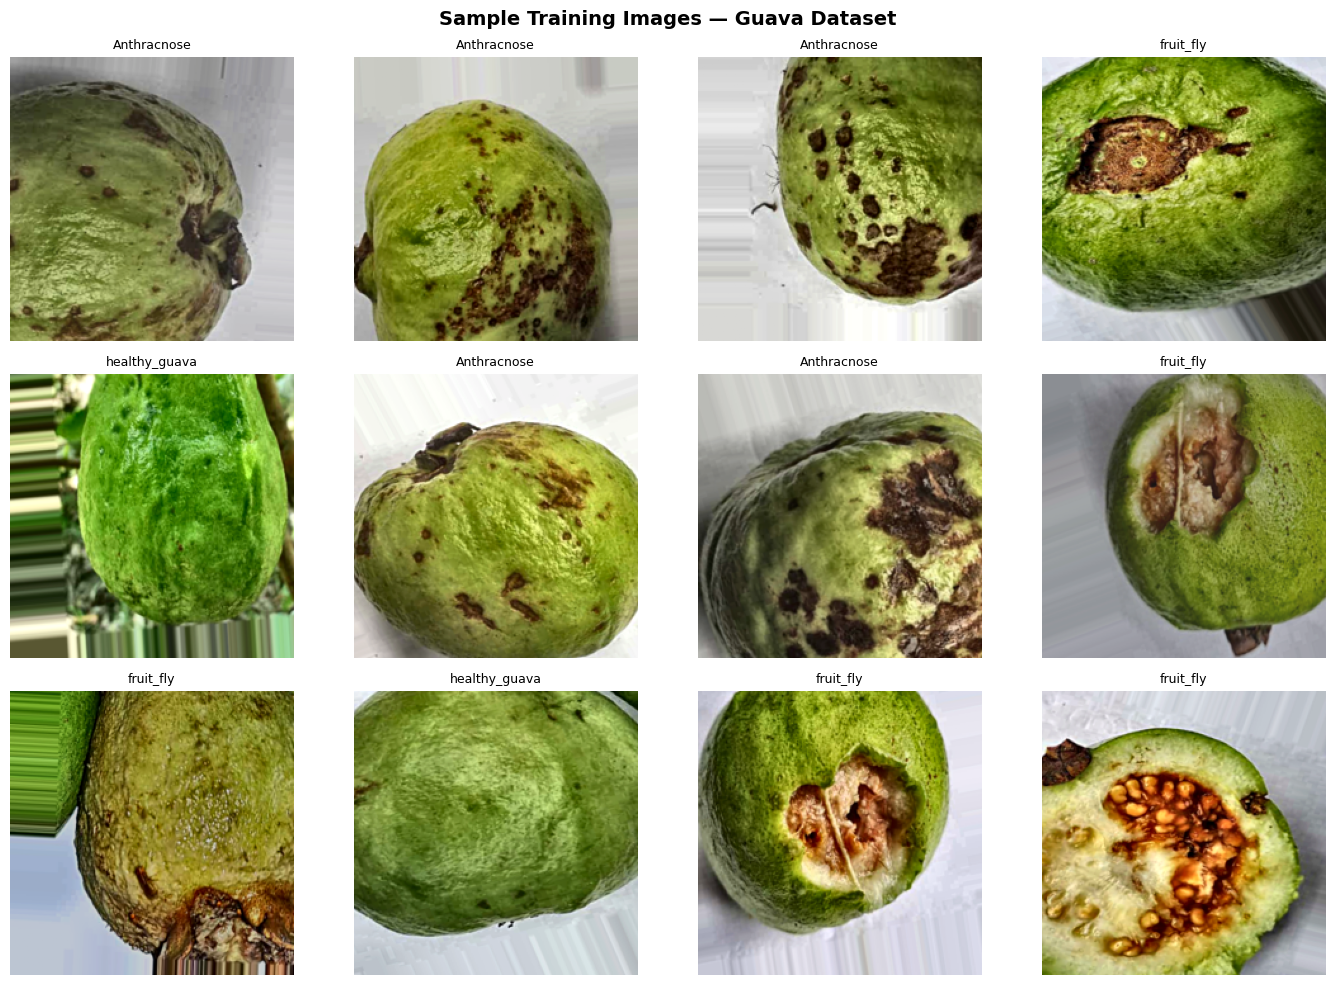

In [7]:
def denormalize(tensor, mean=MEAN, std=STD):
    """
    Reverse ImageNet normalisation so images display with correct colours.
    Input tensor shape: (C, H, W)
    Output numpy shape: (H, W, C) with values in [0, 1]
    """
    m = torch.tensor(mean).view(3, 1, 1)
    s = torch.tensor(std).view(3, 1, 1)
    img = (tensor * s + m).clamp(0, 1)        # undo normalise, clip to [0,1]
    return img.permute(1, 2, 0).numpy()        # (C,H,W) → (H,W,C) for matplotlib

# Pull one batch from the training loader
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle("Sample Training Images — Guava Dataset", fontsize=14, fontweight="bold")

for i, ax in enumerate(axes.flat):
    if i >= len(images):
        ax.axis("off")
        continue
    ax.imshow(denormalize(images[i]))
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Load DeiT with pretrained ImageNet weights
# timm replaces the head automatically when num_classes is set
model = timm.create_model(
    "deit_base_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES   # replaces the 1000-class head with a 3-class head
)

model = model.to(device)

# Confirm the head was replaced correctly
print("Classifier head:", model.head)
# Expected: Linear(in_features=768, out_features=3, bias=True)

# Quick sanity check: run a dummy batch through the model
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = model(dummy)
print(f"Output shape : {out.shape}")    # should be torch.Size([2, 3])

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters : {total_params:,}")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Classifier head: Linear(in_features=768, out_features=3, bias=True)
Output shape : torch.Size([2, 3])
Trainable parameters : 85,800,963


In [9]:
# CrossEntropyLoss is standard for multi-class classification problems
criterion = nn.CrossEntropyLoss()

# Separate the new head from the rest of the (pretrained) backbone
# so we can apply different learning rates to each group
head_params    = list(model.head.parameters())
head_ids       = {id(p) for p in head_params}
backbone_params = [p for p in model.parameters() if id(p) not in head_ids]

# AdamW with two parameter groups:
#   backbone → small lr   (gentle fine-tune; don't destroy pretrained features)
#   head     → larger lr  (needs to learn from scratch quickly)
optimizer = optim.AdamW(
    [
        {"params": backbone_params, "lr": 1e-5},
        {"params": head_params,     "lr": 1e-4},
    ],
    weight_decay=1e-4    # L2 regularisation to reduce overfitting
)

print("Loss      : CrossEntropyLoss")
print("Optimizer : AdamW")
print("  backbone lr = 1e-5")
print("  head lr     = 1e-4")
print("  weight_decay = 1e-4")

Loss      : CrossEntropyLoss
Optimizer : AdamW
  backbone lr = 1e-5
  head lr     = 1e-4
  weight_decay = 1e-4


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Run one full training epoch.

    Steps per batch:
      1. Move data to device
      2. Zero out old gradients
      3. Forward pass → compute loss
      4. Backward pass → compute gradients
      5. Clip gradients (prevents exploding gradients in transformers)
      6. Optimizer step → update weights

    Returns:
        avg_loss (float): mean loss over all training samples
        accuracy (float): fraction of correctly classified samples
    """
    model.train()                              # enable dropout / training behaviour
    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()                  # clear gradients from previous step
        outputs = model(images)                # forward pass → shape (B, num_classes)
        loss    = criterion(outputs, labels)   # compute cross-entropy loss

        loss.backward()                        # backpropagate gradients

        # Gradient clipping is important for transformer models
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()                       # update model weights

        # Accumulate metrics
        running_loss += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)  # predicted class index
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def validate(model, loader, criterion, device):
    """
    Run one full validation pass (no weight updates).

    torch.no_grad() saves memory and speeds things up because
    no computation graph is built for gradients.

    Returns:
        avg_loss (float): mean loss over all validation samples
        accuracy (float): fraction of correctly classified samples
    """
    model.eval()                               # disable dropout / use running stats
    running_loss = 0.0
    correct      = 0
    total        = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds         = outputs.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


print("train_one_epoch() and validate() are defined and ready.")

train_one_epoch() and validate() are defined and ready.


In [11]:
NUM_EPOCHS      = 10
BEST_MODEL_PATH = "/kaggle/working/best_deit_guava.pth"

best_val_acc = 0.0

# Track metrics every epoch for plotting
history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  []
}

print(f"{'Epoch':<8} {'Train Loss':<14} {'Train Acc':<13} "
      f"{'Val Loss':<14} {'Val Acc':<12} {'Note'}")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Training phase ─────────────────────────────────────────────────────────
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # ── Validation phase ───────────────────────────────────────────────────────
    val_loss, val_acc = validate(
        model, val_loader, criterion, device
    )

    # ── Record history ─────────────────────────────────────────────────────────
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # ── Save best model ────────────────────────────────────────────────────────
    note = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        note = "✔  best saved"

    # ── Print epoch summary ────────────────────────────────────────────────────
    print(f"{epoch:<8} {train_loss:<14.4f} {train_acc:<13.4f} "
          f"{val_loss:<14.4f} {val_acc:<12.4f} {note}")

print()
print(f"Training complete.")
print(f"Best validation accuracy : {best_val_acc * 100:.2f}%")
print(f"Best model saved to      : {BEST_MODEL_PATH}")

Epoch    Train Loss     Train Acc     Val Loss       Val Acc      Note
------------------------------------------------------------------------
1        0.2360         0.9316        0.0210         0.9934       ✔  best saved
2        0.0137         0.9955        0.0069         0.9987       ✔  best saved
3        0.0042         0.9989        0.0029         1.0000       ✔  best saved
4        0.0015         1.0000        0.0016         1.0000       
5        0.0011         0.9996        0.0009         1.0000       
6        0.0009         0.9996        0.0037         0.9987       
7        0.0023         0.9996        0.0007         1.0000       
8        0.0002         1.0000        0.0005         1.0000       
9        0.0005         0.9996        0.0003         1.0000       
10       0.0001         1.0000        0.0002         1.0000       

Training complete.
Best validation accuracy : 100.00%
Best model saved to      : /kaggle/working/best_deit_guava.pth


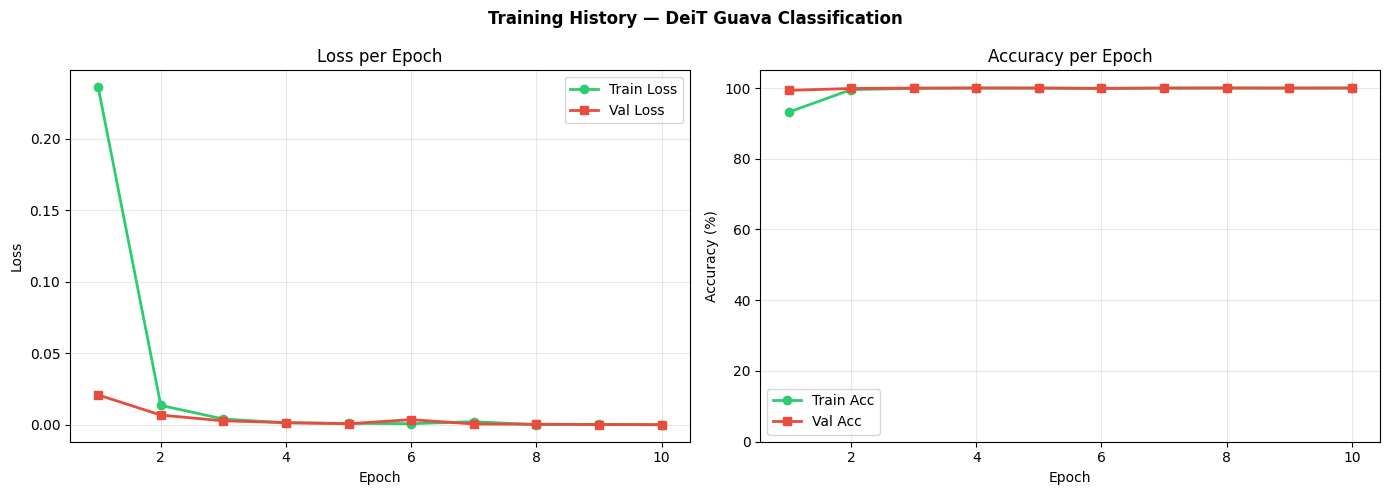

Plot saved to /kaggle/working/training_curves.png


In [12]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History — DeiT Guava Classification", fontweight="bold")

# ── Loss plot ──────────────────────────────────────────────────────────────────
ax1.plot(epochs, history["train_loss"],
         marker="o", linewidth=2, color="#2ecc71", label="Train Loss")
ax1.plot(epochs, history["val_loss"],
         marker="s", linewidth=2, color="#e74c3c", label="Val Loss")
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Accuracy plot ──────────────────────────────────────────────────────────────
ax2.plot(epochs, [a * 100 for a in history["train_acc"]],
         marker="o", linewidth=2, color="#2ecc71", label="Train Acc")
ax2.plot(epochs, [a * 100 for a in history["val_acc"]],
         marker="s", linewidth=2, color="#e74c3c", label="Val Acc")
ax2.set_title("Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0, 105)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to /kaggle/working/training_curves.png")

In [13]:
# Reload the best weights that were saved during training
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()
print(f"Best weights loaded from: {BEST_MODEL_PATH}")

all_preds  = []   # predicted class indices
all_labels = []   # true class indices

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds   = outputs.argmax(dim=1)    # pick the class with the highest score

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall test accuracy
test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy : {test_acc * 100:.2f}%  "
      f"({int((all_preds == all_labels).sum())} / {len(all_labels)} correct)")

Best weights loaded from: /kaggle/working/best_deit_guava.pth
Test Accuracy : 99.74%  (381 / 382 correct)


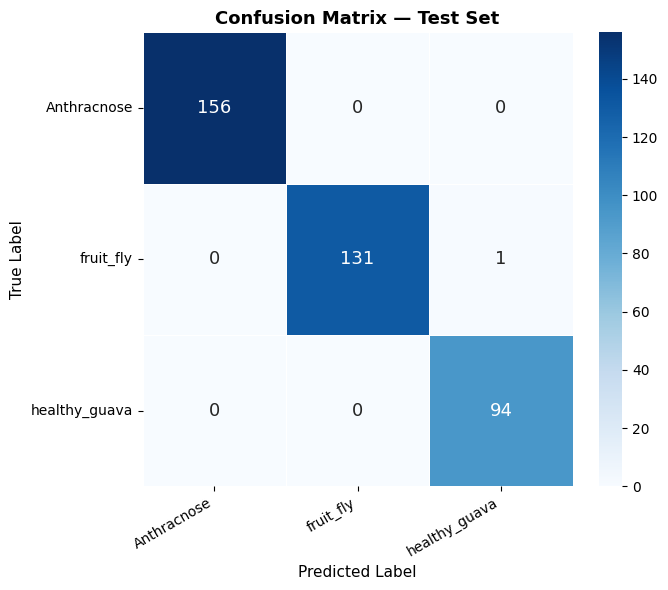

Confusion matrix saved to /kaggle/working/confusion_matrix.png

Classification Report:
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

  Anthracnose     1.0000    1.0000    1.0000       156
    fruit_fly     1.0000    0.9924    0.9962       132
healthy_guava     0.9895    1.0000    0.9947        94

     accuracy                         0.9974       382
    macro avg     0.9965    0.9975    0.9970       382
 weighted avg     0.9974    0.9974    0.9974       382



In [14]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",                          # show raw counts (integers)
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    annot_kws={"size": 13}
)
plt.title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label",      fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved to /kaggle/working/confusion_matrix.png")

# ── Classification report ──────────────────────────────────────────────────────
print("\nClassification Report:")
print("─" * 60)
print(
    classification_report(
        all_labels, all_preds,
        target_names=CLASS_NAMES,
        digits=4
    )
)

In [15]:
# Verify the checkpoint file was written
if os.path.exists(BEST_MODEL_PATH):
    size_mb = os.path.getsize(BEST_MODEL_PATH) / (1024 ** 2)
    print(f"✔  Best model found at : {BEST_MODEL_PATH}")
    print(f"   File size           : {size_mb:.1f} MB")
else:
    print("✘  Model file not found — make sure Cell 9 ran successfully.")

# ─────────────────────────────────────────────────────────────────────────────
# HOW TO RELOAD THIS MODEL IN A NEW SESSION
# Run the lines below in any new notebook where you need the trained weights:
# ─────────────────────────────────────────────────────────────────────────────
#
# import timm, torch
# model = timm.create_model("deit_base_patch16_224",
#                            pretrained=False,
#                            num_classes=3)
# model.load_state_dict(torch.load("/kaggle/working/best_deit_guava.pth",
#                                   map_location=device))
# model = model.to(device)
# model.eval()
#
# ─────────────────────────────────────────────────────────────────────────────
print("\nSee the comments above for how to reload this model later.")

✔  Best model found at : /kaggle/working/best_deit_guava.pth
   File size           : 327.4 MB

See the comments above for how to reload this model later.


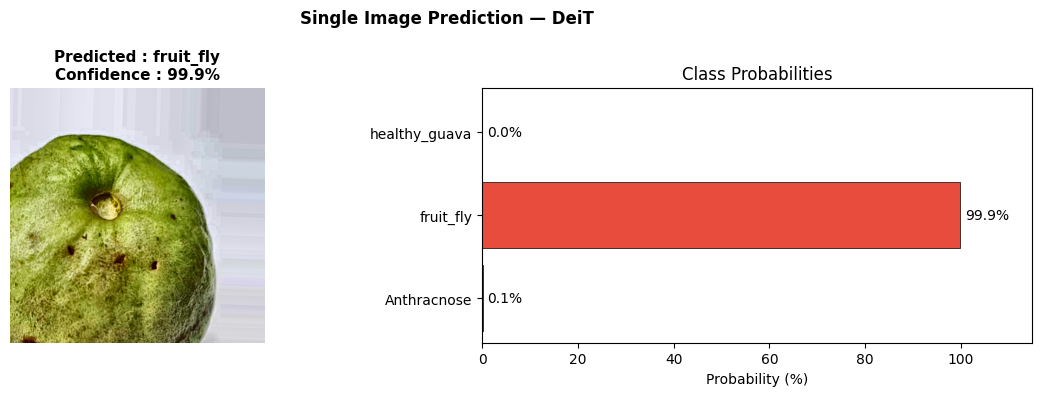


Final result → Predicted class : fruit_fly
               Confidence      : 99.93%


In [16]:
def predict_single_image(image_path, model, transform, idx_to_class, device):
    """
    Predict the disease class of a single guava image.

    Args:
        image_path   : full path to the image file (PNG, JPG, etc.)
        model        : trained DeiT model already moved to device
        transform    : the val/test transform pipeline (same as used in evaluation)
        idx_to_class : dict mapping integer index → class name string
        device       : torch.device (cuda or cpu)

    Returns:
        pred_class  (str)   : predicted class name
        confidence  (float) : probability of the predicted class
    """
    # ── Load and preprocess ────────────────────────────────────────────────────
    img = Image.open(image_path).convert("RGB")     # ensure 3-channel RGB
    tensor = transform(img).unsqueeze(0).to(device) # add batch dim → (1,3,224,224)

    # ── Inference ──────────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        logits = model(tensor)                        # raw class scores
        probs  = torch.softmax(logits, dim=1)[0]      # convert to probabilities

    pred_idx   = probs.argmax().item()
    pred_class = idx_to_class[pred_idx]
    confidence = probs[pred_idx].item()

    # ── Display ────────────────────────────────────────────────────────────────
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Single Image Prediction — DeiT", fontweight="bold")

    # Left panel: the image itself
    ax_img.imshow(img)
    ax_img.set_title(
        f"Predicted : {pred_class}\nConfidence : {confidence * 100:.1f}%",
        fontsize=11, fontweight="bold"
    )
    ax_img.axis("off")

    # Right panel: horizontal bar chart of all class probabilities
    class_labels = [idx_to_class[i] for i in range(len(idx_to_class))]
    prob_values  = [probs[i].item() * 100 for i in range(len(idx_to_class))]

    # Colour the predicted class differently
    bar_colors = ["#3498db"] * len(class_labels)
    bar_colors[pred_idx] = "#e74c3c"

    bars = ax_bar.barh(class_labels, prob_values,
                       color=bar_colors, edgecolor="black", linewidth=0.5)
    ax_bar.set_xlabel("Probability (%)")
    ax_bar.set_title("Class Probabilities")
    ax_bar.set_xlim(0, 115)

    # Add percentage labels at the end of each bar
    for bar, val in zip(bars, prob_values):
        ax_bar.text(
            val + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center", fontsize=10
        )

    plt.tight_layout()
    plt.show()

    return pred_class, confidence


# ── Run the prediction ─────────────────────────────────────────────────────────
# Change this path to any real image from your test folder.
# Example: pick the first image from the Anthracnose test folder.
sample_image_path = "/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/val/fruit_fly/100_unsharp_clahe_augmented_4.png"
# ↑ CHANGE THIS to an actual image filename in your dataset

predicted_class, conf = predict_single_image(
    sample_image_path,
    model,
    val_test_transforms,   # use the same transforms as validation / test
    idx_to_class,
    device
)

print(f"\nFinal result → Predicted class : {predicted_class}")
print(f"               Confidence      : {conf * 100:.2f}%")

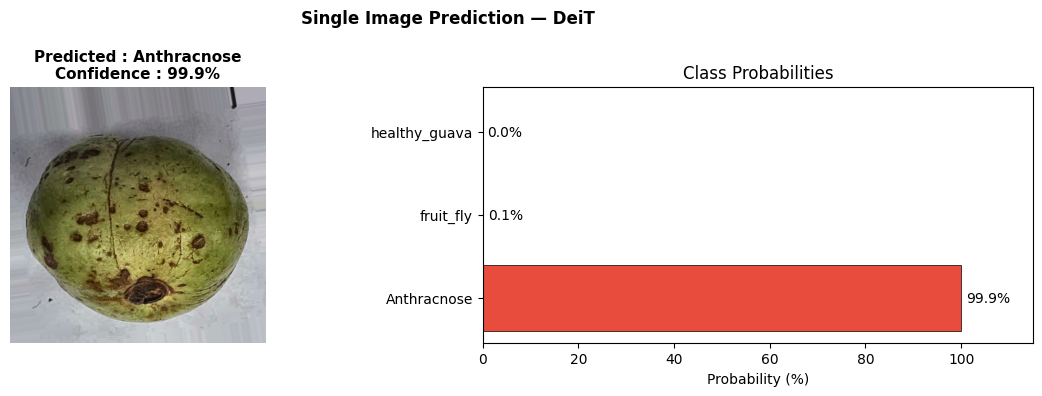


Final result → Predicted class : Anthracnose
               Confidence      : 99.94%


In [17]:
def predict_single_image(image_path, model, transform, idx_to_class, device):
    """
    Predict the disease class of a single guava image.

    Args:
        image_path   : full path to the image file (PNG, JPG, etc.)
        model        : trained DeiT model already moved to device
        transform    : the val/test transform pipeline (same as used in evaluation)
        idx_to_class : dict mapping integer index → class name string
        device       : torch.device (cuda or cpu)

    Returns:
        pred_class  (str)   : predicted class name
        confidence  (float) : probability of the predicted class
    """
    # ── Load and preprocess ────────────────────────────────────────────────────
    img = Image.open(image_path).convert("RGB")     # ensure 3-channel RGB
    tensor = transform(img).unsqueeze(0).to(device) # add batch dim → (1,3,224,224)

    # ── Inference ──────────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        logits = model(tensor)                        # raw class scores
        probs  = torch.softmax(logits, dim=1)[0]      # convert to probabilities

    pred_idx   = probs.argmax().item()
    pred_class = idx_to_class[pred_idx]
    confidence = probs[pred_idx].item()

    # ── Display ────────────────────────────────────────────────────────────────
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Single Image Prediction — DeiT", fontweight="bold")

    # Left panel: the image itself
    ax_img.imshow(img)
    ax_img.set_title(
        f"Predicted : {pred_class}\nConfidence : {confidence * 100:.1f}%",
        fontsize=11, fontweight="bold"
    )
    ax_img.axis("off")

    # Right panel: horizontal bar chart of all class probabilities
    class_labels = [idx_to_class[i] for i in range(len(idx_to_class))]
    prob_values  = [probs[i].item() * 100 for i in range(len(idx_to_class))]

    # Colour the predicted class differently
    bar_colors = ["#3498db"] * len(class_labels)
    bar_colors[pred_idx] = "#e74c3c"

    bars = ax_bar.barh(class_labels, prob_values,
                       color=bar_colors, edgecolor="black", linewidth=0.5)
    ax_bar.set_xlabel("Probability (%)")
    ax_bar.set_title("Class Probabilities")
    ax_bar.set_xlim(0, 115)

    # Add percentage labels at the end of each bar
    for bar, val in zip(bars, prob_values):
        ax_bar.text(
            val + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center", fontsize=10
        )

    plt.tight_layout()
    plt.show()

    return pred_class, confidence


# ── Run the prediction ─────────────────────────────────────────────────────────
# Change this path to any real image from your test folder.
# Example: pick the first image from the Anthracnose test folder.
sample_image_path = "/kaggle/input/datasets/habibsalehinshamun/guavadiseasedataset-cnn/GuavaDiseaseDataset/train/Anthracnose/100_unsharp_clahe_augmented_2.png"
# ↑ CHANGE THIS to an actual image filename in your dataset

predicted_class, conf = predict_single_image(
    sample_image_path,
    model,
    val_test_transforms,   # use the same transforms as validation / test
    idx_to_class,
    device
)

print(f"\nFinal result → Predicted class : {predicted_class}")
print(f"               Confidence      : {conf * 100:.2f}%")